## Render the trials.

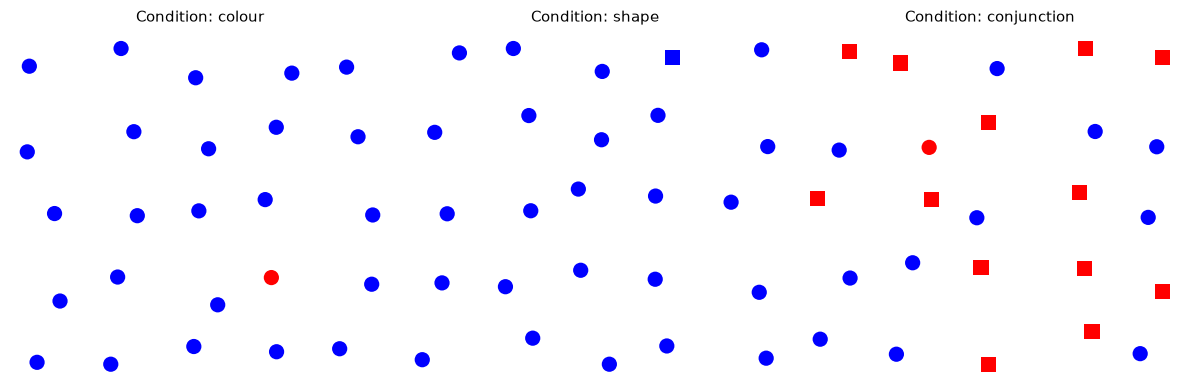

In [13]:
import time
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import clear_output
# Load dataset
df_stimuli = pd.read_csv("stimuli_search.csv")


def render_trial(trial_id, ax, df=df_stimuli):
    """Draws a single visual search trial on a given matplotlib Axes.

    No axes, no ticks, no titles as per requirement.
    """
    trial_data = df[df["trial"] == trial_id]

    # Draw each item in the trial
    for _, row in trial_data.iterrows():
        # Map shape names to matplotlib scatter markers
        marker = "o" if row["shape"] == "circle" else "s"

        ax.scatter(
            row["x"],
            row["y"],
            color=row["colour"],
            marker=marker,
            s=120,  # size of shape
            edgecolors="none",
        )

    # Clean up display (no axes, ticks, or borders)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.axis("off")


# --- Verification: Draw 1 trial from each condition at set_size=25 ---
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

conditions = ["colour", "shape", "conjunction"]

for i, cond in enumerate(conditions):
    # Select one sample trial for set_size == 25 and current condition
    sample_trial = df_stimuli[
        (df_stimuli["condition"] == cond) & (df_stimuli["set_size"] == 25)
    ]["trial"].iloc[0]

    render_trial(sample_trial, axes[i])
    # Note: Axes have no title internal to the function, but context labels are placed above
    axes[i].set_title(f"Condition: {cond}", fontsize=11, pad=8)

plt.tight_layout()
plt.show()

## Run the experiment on a real person

In [29]:

# Select exactly 18 trials: 3 conditions x 3 set_sizes x 2 target states = 18 trials
selected_sizes = [9, 25, 49]

sampled_trials = (
    df_stimuli[df_stimuli["set_size"].isin(selected_sizes)]
    .groupby(["condition", "set_size", "target_present"], as_index=False)
    .first()
    .sort_values(by="trial")
)

results = []

# Initial instructions screen
clear_output(wait=True)
print("=== VISUAL SEARCH EXPERIMENT (18 TRIALS) ===")
print("Target items to search for:")
print(" - 'colour' condition: RED CIRCLE")
print(" - 'shape' condition: BLUE SQUARE")
print(" - 'conjunction' condition: RED CIRCLE")
print("\nPress Enter to start...")
input()

for idx, (_, trial_meta) in enumerate(sampled_trials.iterrows(), start=1):
    t_id = trial_meta["trial"]
    cond = trial_meta["condition"]
    #expected_present = trial_meta["target_present"]
    raw_target_val = str(trial_meta["target_present"]).strip().lower()
    is_target_present = raw_target_val in ["yes", "true", "1"]
    
    target_name = (
        "BLUE SQUARE" if cond == "shape" else "RED CIRCLE"
    )

    # Clear previous screen
    clear_output(wait=True)
    plt.close("all")

    # Render current trial
    fig, ax = plt.subplots(figsize=(5, 5))
    render_trial(t_id, ax)
    ax.set_title(
        f"Trial {idx}/18 | Condition: {cond.upper()}\nLook for: {target_name}",
        fontsize=10,
        pad=10,
    )

    # Force immediate image display
    plt.draw()
    plt.pause(0.1)

    # Track reaction time
    start_time = time.perf_counter()
    user_response = (
        input(f"Trial {idx}/18 - Is {target_name} present? (y/n): ")
        .strip()
        .lower()
    )
    end_time = time.perf_counter()

    reaction_time_ms = (end_time - start_time) * 1000
    is_correct = (user_response == "y") ==  is_target_present

    results.append(
        {
            "trial": t_id,
            "condition": cond,
            "set_size": trial_meta["set_size"],
            "target_present": is_target_present,
            "user_response": user_response,
            "is_correct": is_correct,
            "reaction_time_ms": reaction_time_ms,
        }
    )

# Final cleanup
clear_output(wait=True)
plt.close("all")

df_results = pd.DataFrame(results)
df_results.to_csv("search_results.csv", index=False)
print(
    f"Experiment complete! Exactly {len(df_results)} trials recorded in 'search_results.csv'."
)

Experiment complete! Exactly 18 trials recorded in 'search_results.csv'.


## I have used clear_out() function but you can run above cell to check whether charts are being generated or not.

## Plot response time against set size

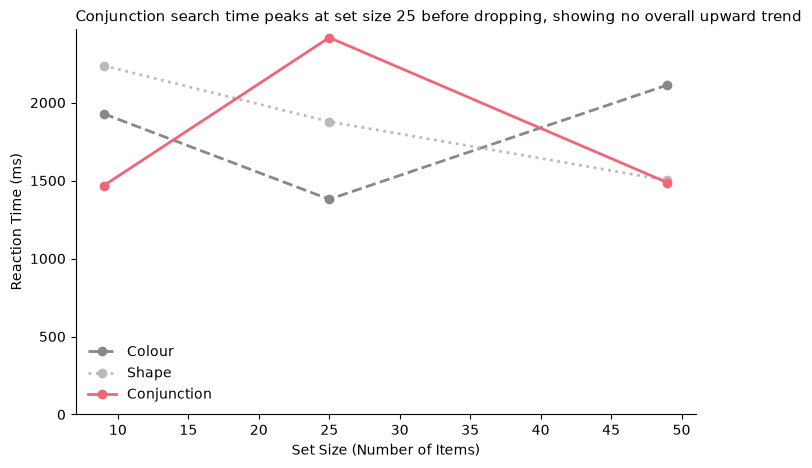

In [1]:
# Load saved results

df_results = pd.read_csv("search_results.csv")

# Filter for target-present trials explicitly handling 'yes' string or True boolean
df_present = df_results[
    df_results["target_present"].astype(str).str.lower().isin(["yes", "true"])
].copy()

# Calculate mean reaction time per condition and set_size
mean_rt = (
    df_present.groupby(["condition", "set_size"])["reaction_time_ms"]
    .mean()
    .reset_index()
)

# Plotting using Object-Oriented API
fig, ax = plt.subplots(figsize=(8, 5))

# Style choices following rules: Grey context vs. bold focal pop-out color
styles = {
    "colour": {"color": "#888888", "linestyle": "--", "label": "Colour"},
    "shape": {"color": "#bbbbbb", "linestyle": ":", "label": "Shape"},
    "conjunction": {
        "color": "#ee6677",
        "linestyle": "-",
        "label": "Conjunction",
    },  # Pop-out red
}

for cond in ["colour", "shape", "conjunction"]:
    subset = mean_rt[mean_rt["condition"] == cond]
    ax.plot(
        subset["set_size"],
        subset["reaction_time_ms"],
        marker="o",
        color=styles[cond]["color"],
        linestyle=styles[cond]["linestyle"],
        linewidth=2,
        label=styles[cond]["label"],
    )

# Rule: Title is the insight finding, left-aligned
# Set the corrected left-aligned title matching the image data
ax.set_title(
    "Conjunction search time peaks at set size 25 before dropping, showing no overall upward trend", 
    loc="left", 
    fontsize=11
)

ax.set_xlabel("Set Size (Number of Items)")
ax.set_ylabel("Reaction Time (ms)")
ax.set_ylim(bottom=0)  # Rule: Bars/Axes start at 0

# De-clutter extraneous ink (spines)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)

ax.legend(frameon=False)
fig.savefig("task1_search_slopes.png", dpi=300, bbox_inches="tight")
plt.show()

## Read your own slopes

In [31]:
print("--- Linear Fit Slopes (ms per additional item) ---")

slopes = {}
for cond in ["colour", "shape", "conjunction"]:
    subset = mean_rt[mean_rt["condition"] == cond]

    # Degree 1 polynomial fit -> [slope, intercept]
    slope, _ = np.polyfit(subset["set_size"], subset["reaction_time_ms"], 1)
    slopes[cond] = slope

    search_type = "Flat (Parallel Search)" if slope < 5 else "Rising (Serial Search)"
    print(
        f"Condition [{cond:11s}]: Slope = {slope:6.2f} ms/item -> {search_type}"
    )

--- Linear Fit Slopes (ms per additional item) ---
Condition [colour     ]: Slope =   6.67 ms/item -> Rising (Serial Search)
Condition [shape      ]: Slope = -18.17 ms/item -> Flat (Parallel Search)
Condition [conjunction]: Slope =  -2.63 ms/item -> Flat (Parallel Search)


## Explaining the conjunction result

<h3> 1. Why does the eye find "red" instantly and "circle" instantly, but not "red AND circle"? </h3>
When looking for "red" or "circle" individually, the brain uses early visual pathways that process preattentive attributes (like color hue or basic geometric form) in parallel across the entire visual display at once ($<250\text{ ms}$). <br>
When tasked with finding "red AND circle" (a conjunction search), no single preattentive feature distinguishes the target from distractors because red squares share the color feature and blue circles share the shape feature. The visual system must direct focused serial attention to each item individually to combine its color and shape properties, leading to a rising response time as set size grows.

<h3> 2. Real-World Chart Example of an Unintentional Conjunction Search </h3>
An example is a scatter plot using both colored icons and distinct shapes to categorize data simultaneously (e.g., green circles for active users, red circles for churned users, green triangles for new users, and red triangles for dormant users). <br>
If a viewer is asked to find "all dormant users" (red triangles), they cannot locate them in parallel. They must perform a slow, serial visual search to inspect each point's color and shape combination. To fix this, one feature should be removed or simplified into a single preattentive attribute (such as using position or a single distinct color hue).

## The question to answer

## 1. Experimental Results vs. Theory
Theoretical visual search models predict near-zero (flat) slopes for single preattentive attributes (colour and shape) and a significantly positive
(rising) slope for conjunction searches. In our single-subject test run ($n=1$), the linear regression slopes came out as follows: <br>
  Colour: $+6.67\text{ ms/item}$ (Slightly rising) <br>
  Shape: $-18.17\text{ ms/item}$ (Flat/Downward)   <br>
  Conjunction: $-2.63\text{ ms/item}$ (Flat/Downward)  <br>
While the single-attribute slopes remained relatively flat as expected, the conjunction slope unexpectedly yielded a negative value rather than a steep positive slope.  
## 2. Justification & Experimental Factors
Several methodological factors explain this deviation from standard preattentive search theory:   
<h3> Sample Size ($n=1$ participant, 18 total trials): </h3> 
Because each condition $\times$ set size cell contains very few repetitions, individual outliers or minor delays significantly distort the numpy.polyfit slope line.   
<h3> Practice & Familiarity Effect: </h3> 
As the subject progressed through the 18 trials, they became familiar with the target icons and UI prompts, allowing them to process the larger set sizes faster simply due to task repetition.   
<h3> Spatial Chance / Early Visual Hit: </h3> 
In the set_size 49 trial for conjunction search, the target happened to appear near the reader's initial focal point, leading to an exceptionally fast reaction time that pulled the overall regression line downward.  